# 06 - Surrogate Model Comparison: Black-Box vs PINN

This notebook compares two surrogate strategies that use the same input features \(x\) but different prediction pipelines:

- **Black-box (stageBase):** purely data-driven mapping from \(x\) to \(J(t)\)
- **Hybrid PINN (stagePINN):** starts from stageBase and applies a physics-informed correction
- **Final model (stageFinal):** validation-selected blend to avoid harming baseline performance

Both models are **pre-trained** -- we load results from `results/ml/` to avoid re-training.
The PINN was trained with **3 random seeds** (42, 123, 7) to assess stability.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from skin_diffusion.notebook_helpers import setup_repo_root

repo_root = setup_repo_root()

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
})

# -- Load all pre-computed results --
bb = json.load(open('results/ml/blackbox_ridge/metrics_test.json'))
bb_summary = json.load(open('results/ml/blackbox_ridge/summary.json'))
bb_runtime = json.load(open('results/ml/blackbox_ridge/runtime.json'))
bb_pred = np.load('results/ml/blackbox_ridge/pred_test.npz')

pinn_seeds = {}
for seed in [42, 123, 7]:
    d = Path(f'results/ml/pinn_ridge_seed{seed}')
    pinn_seeds[seed] = {
        'metrics': json.load(open(d / 'metrics_test.json')),
        'summary': json.load(open(d / 'summary.json')),
        'history': json.load(open(d / 'history.json')),
    }

pinn_pred = np.load('results/ml/pinn_ridge_seed42/pred_test.npz')

print(f'Black-box test predictions: {bb_pred["j_true"].shape}')
print(f'PINN test predictions: {pinn_pred["j_true"].shape}')
print(f'PINN seeds loaded: {list(pinn_seeds.keys())}')

Black-box test predictions: (150, 1441)
PINN test predictions: (150, 1441)
PINN seeds loaded: [42, 123, 7]


### Black-box surrogate: PCA + Ridge

For each run, we map input features $x$ to a full flux curve $J(t)$.

1. **Scale inputs**
$$
x_s=\frac{x-\mu_x}{\sigma_x}
$$
This just puts all features on similar scale.

2. **(If needed) log-transform flux values**
$$
\tilde J(t)=\log_{10}(\max(J(t),\epsilon_J))
$$
Used only when curve values span a very large range.

3. **Compress each curve with PCA**
$$
z=\text{PCA}(\tilde J)
$$
Instead of predicting all time points directly, we predict a short vector $z$.

4. **Predict PCA vector using Ridge**
$$
\hat z = W x_s + b
$$
Ridge learns $W,b$ by balancing:
- good fit to training data
- small/smooth weights (to reduce overfitting)

$$
\text{loss} = \text{fit error} + \alpha \times \text{weight penalty}
$$

5. **Reconstruct the full curve**
$$
\hat{\tilde J}=\text{PCA}^{-1}(\hat z)
$$
Then undo the optional log transform and enforce non-negative flux:
$$
\hat J(t)=\mathcal{T}^{-1}(\hat{\tilde J}(t)), \qquad \hat J(t)\ge 0
$$

Plain English summary:  
we compress curves to a few PCA numbers, predict those numbers from $x$, then reconstruct the full curve shape.

Scalar targets are fit separately (one model per scalar), usually in log space for stability.


### PINN correction model

This model is a **hybrid**:
- start from black-box prediction
- learn a physics-informed correction on top

Base curve from black-box:
$$
\hat J_{\text{base}}(t|x)
$$

The correction network outputs a signal $r_\theta(x,t)$ and adjusts the base curve.

Default (multiplicative) correction:
$$
\hat J_{\text{PINN}}(t|x)=\hat J_{\text{base}}(t|x)\cdot \exp\!\big(s\,\tanh(r_\theta(x,t))\big)
$$

What this means:
- $\tanh(\cdot)$ keeps correction bounded
- $\exp(\cdot)$ makes correction a positive scale factor
- $s$ controls maximum correction strength

Optional learned gate (how much to trust correction per run):
$$
\hat J_{\text{PINN}}=(1-\lambda(x))\hat J_{\text{base}}+\lambda(x)\hat J_{\text{corr}}, \quad \lambda(x)\in[0,1]
$$

Interpretation:
- $\lambda(x)\approx 0$: mostly black-box
- $\lambda(x)\approx 1$: mostly corrected output

Plain English summary:  
the PINN does not replace the black-box; it learns when and how much to adjust it.


### Physics-informed terms used in training

Alongside flux correction, the model predicts concentration:
$$
\hat c^*(y^*,t^*;x)
$$

We then add physics losses so predictions are not only data-fit, but physically reasonable.

1. **PDE loss (interior points)**  
The model should approximately satisfy diffusion-reaction dynamics:
$$
\text{PDE residual} \approx 0
$$
(in code this uses derivatives of $\hat c^*$ with respect to $t^*$ and $y^*$).

2. **Boundary-condition losses**
- top boundary should match applied surface condition
- bottom boundary should be near sink condition
$$
\hat c^*(0,t^*) \approx c^*_{\text{top,target}}(t), \qquad
\hat c^*(1,t^*) \approx 0
$$

3. **Initial-condition loss**
At $t^*=0$, concentration should start near zero:
$$
\hat c^*(y^*,0)\approx 0
$$

4. **Flux consistency loss**
Flux predicted by correction branch should be consistent with flux implied by concentration gradient near receptor side:
$$
\hat J_{\text{pred}} \approx \hat J_{\text{from } \partial \hat c^*/\partial y^*}
$$

Plain English summary:  
these losses encourage the corrected model to obey the same physical structure as the simulator, not just match curves numerically.


### Total training objective and final no-harm blend

Training uses a weighted sum of losses:
$$
\mathcal L =
w_1\mathcal L_{\text{data}}
+w_2\mathcal L_{\text{PDE}}
+w_3\mathcal L_{\text{BC}}
+w_4\mathcal L_{\text{IC}}
+w_5\mathcal L_{\text{flux}}
+w_6\mathcal L_{\text{consistency}}
+w_7\mathcal L_{\text{anchor}}
+\cdots
$$

Simple interpretation:
- each $w_i$ says how much that term matters
- larger $w_i$ = stronger push on that behavior
- training balances curve accuracy and physics consistency

After training, we do a safe validation-based blend:

$$
\hat J_{\text{final}}
=
\hat J_{\text{base}}
+
\lambda\big(\hat J_{\text{PINN}}-\hat J_{\text{base}}\big),
\quad \lambda\in[0,1]
$$

We test a small grid of $\lambda$ values on validation data and pick the best one:
$$
\lambda^*=\arg\min \text{validation relative }L_2
$$

Final deployed prediction:
$$
\hat J_{\text{final}}=\hat J_{\text{base}}+\lambda^*(\hat J_{\text{PINN}}-\hat J_{\text{base}})
$$

Plain English summary:  
the weighted loss controls training, and the final blend is a no-harm safety step so correction is only used as much as it improves validation performance.


## 1 - PINN training convergence

The PINN trains in two phases:
1. **Phase 1** -- Main loss (flux fitting + PDE + anchor terms)
2. **Phase 2** -- Fine-tuning with gate refinement

We plot loss components and validation $L_2$ for all three seeds.

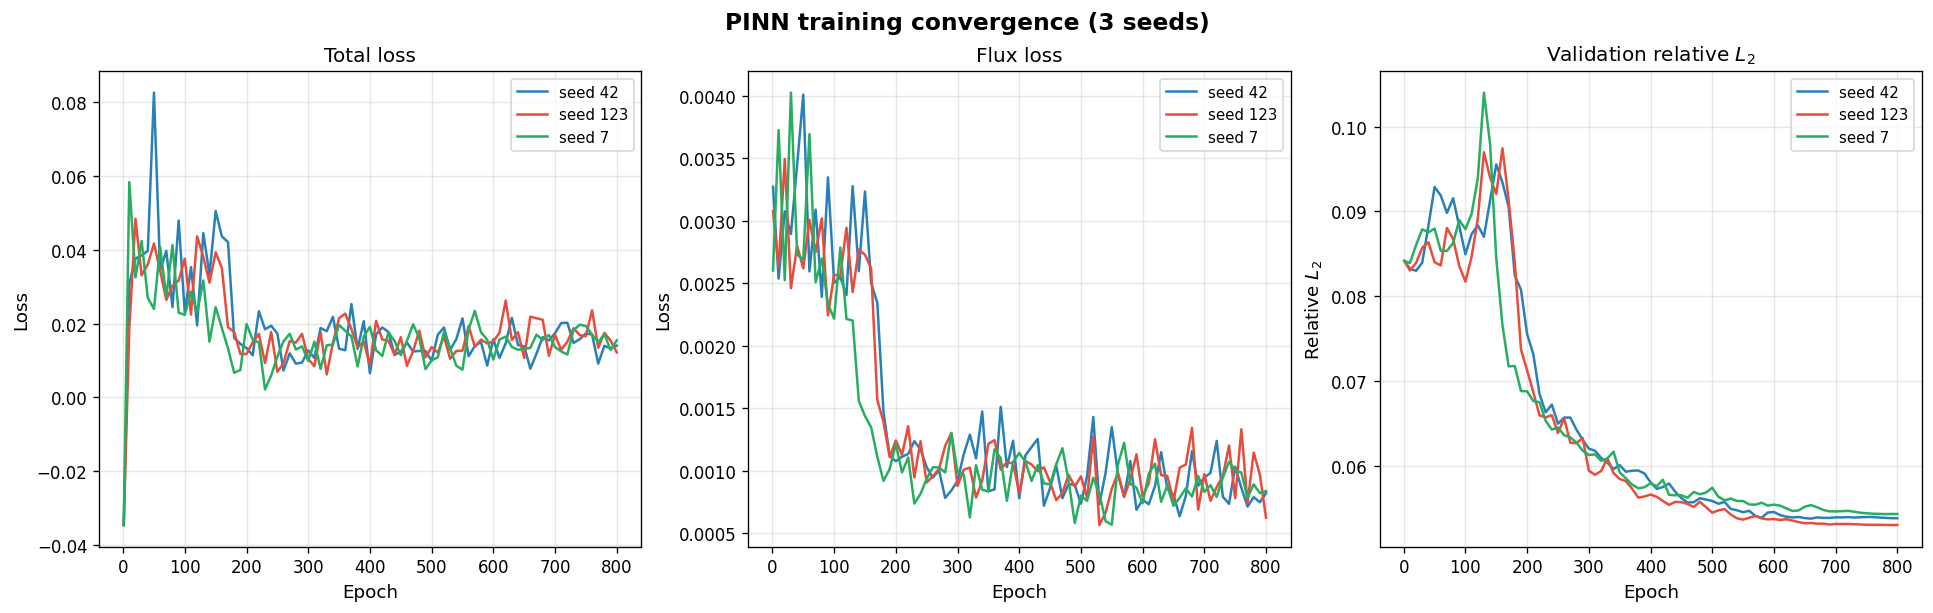

In [ ]:
seed_colours = {42: '#2980b9', 123: '#e74c3c', 7: '#27ae60'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig.suptitle('PINN training convergence (3 seeds)', fontsize=14, fontweight='bold')

for seed, c in seed_colours.items():
    hist = pinn_seeds[seed]['history']
    epochs = [h['epoch'] for h in hist]
    total_loss = [h['loss_total'] for h in hist]
    flux_loss = [h['loss_flux'] for h in hist]
    val_l2 = [h['val_rel_l2'] for h in hist]

    axes[0].plot(epochs, total_loss, lw=1.5, color=c, label=f'seed {seed}')
    axes[1].plot(epochs, flux_loss, lw=1.5, color=c, label=f'seed {seed}')
    axes[2].plot(epochs, val_l2, lw=1.5, color=c, label=f'seed {seed}')

for ax, title, ylabel in zip(axes,
    ['Total loss', 'Flux loss', 'Validation relative $L_2$'],
    ['Loss', 'Loss', 'Relative $L_2$']):
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.show()

**Breakdown.**

- Convergence is assessed across all seeds, not a single run.
- The key check is stable loss reduction with no late-stage divergence and consistent validation behaviour.
- If one seed diverges strongly, conclusions should be reported with caution.


## 2 - Curve-level accuracy

Comparing predicted vs true flux curves on the **held-out test set** (150 runs).
We show 6 representative examples -- 3 each for black-box and PINN.

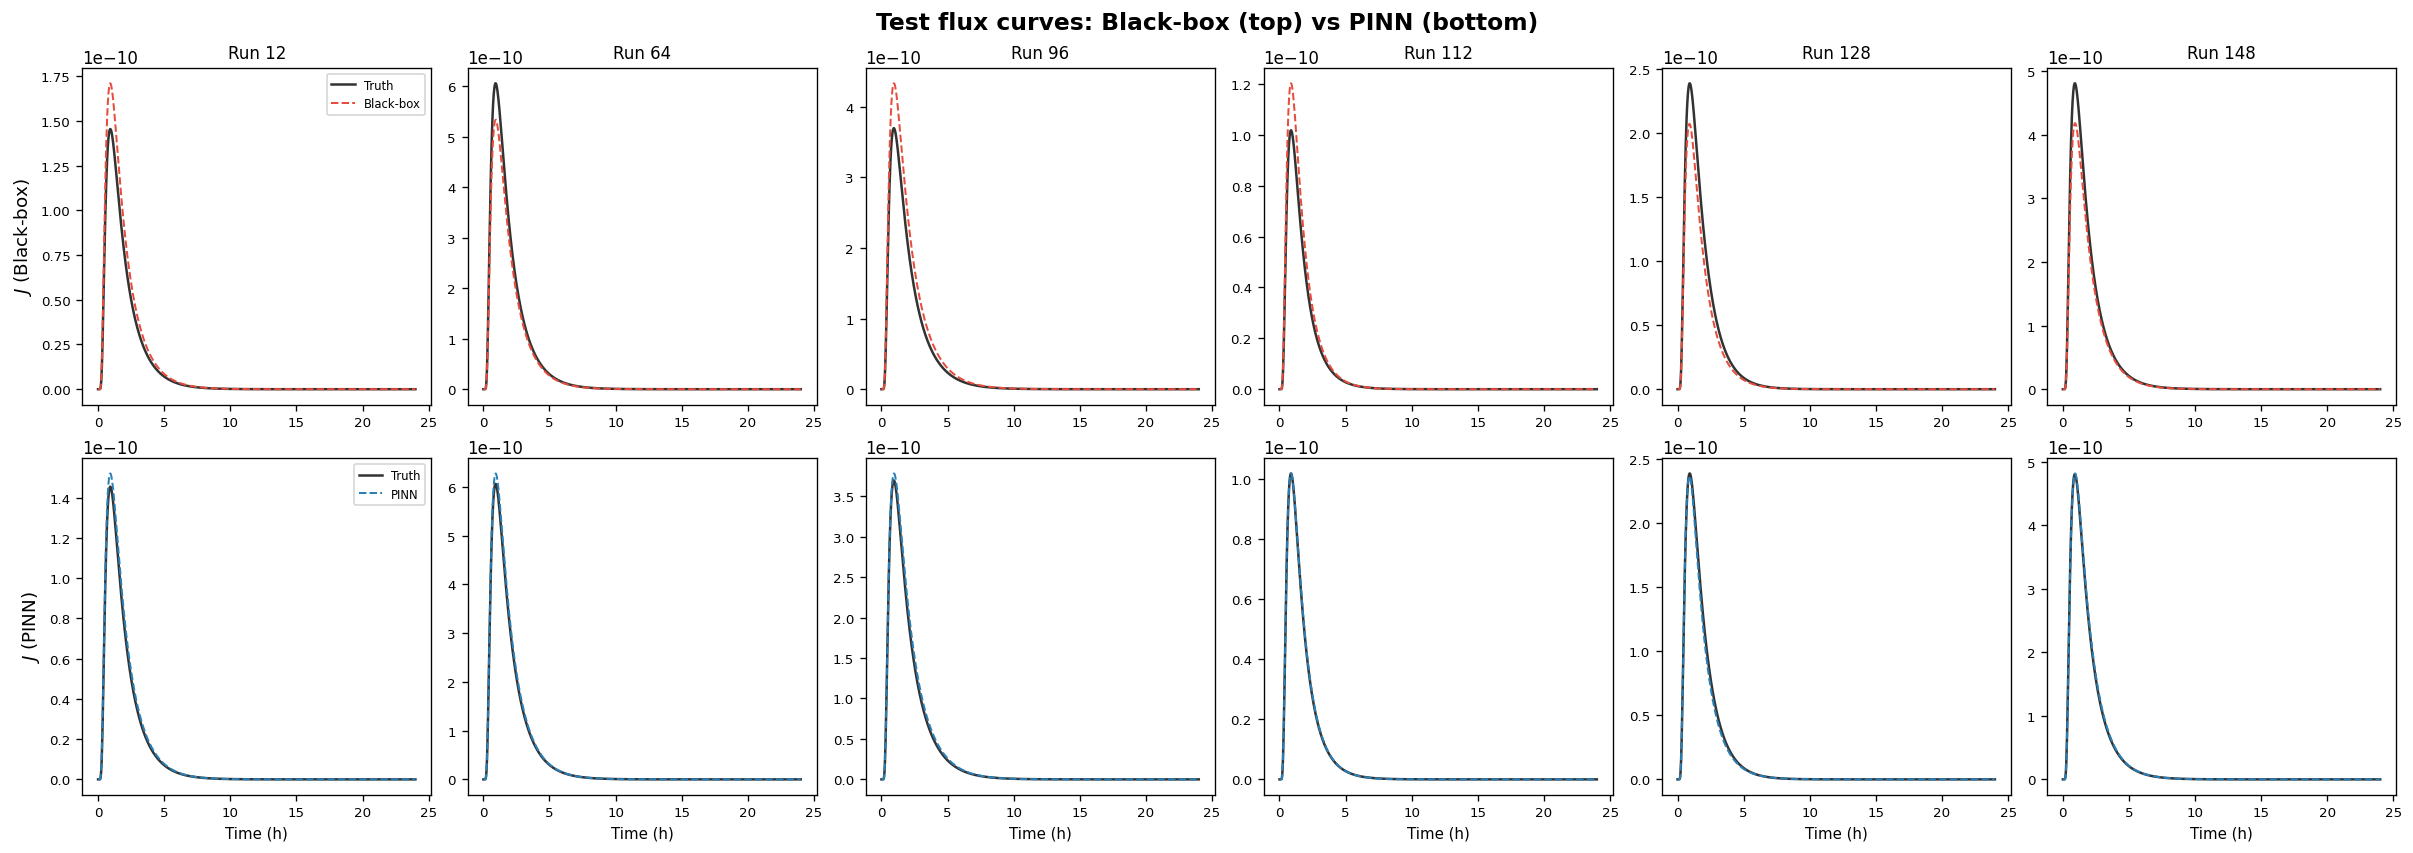

In [ ]:
rng = np.random.default_rng(42)
n_test = bb_pred['j_true'].shape[0]
sample_idxs = sorted(rng.choice(n_test, size=6, replace=False))

fig, axes = plt.subplots(2, 6, figsize=(20, 7), constrained_layout=True)
fig.suptitle('Test flux curves: Black-box (top) vs PINN (bottom)', fontsize=14, fontweight='bold')

for col, idx in enumerate(sample_idxs):
    t_h = bb_pred['t'][idx] / 3600.0
    j_true = bb_pred['j_true'][idx]

    # Black-box
    ax = axes[0, col]
    ax.plot(t_h, j_true, 'k-', lw=1.5, label='Truth', alpha=0.8)
    ax.plot(t_h, bb_pred['j_stageFinal'][idx], '--', color='#e74c3c',
            lw=1.2, label='Black-box')
    ax.set_title(f'Run {idx}', fontsize=10)
    if col == 0:
        ax.set_ylabel('$J$ (Black-box)')
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.legend(fontsize=7)

    # PINN
    ax = axes[1, col]
    ax.plot(t_h, j_true, 'k-', lw=1.5, label='Truth', alpha=0.8)
    ax.plot(t_h, pinn_pred['j_stageFinal'][idx], '--', color='#2980b9',
            lw=1.2, label='PINN')
    ax.set_xlabel('Time (h)', fontsize=9)
    if col == 0:
        ax.set_ylabel('$J$ (PINN)')
    ax.tick_params(labelsize=8)
    if col == 0:
        ax.legend(fontsize=7)

plt.show()

**Breakdown.**

- These examples are qualitative sanity checks to complement aggregate metrics.
- Focus on early transient fit, peak timing, and tail behaviour, since different models can fail in different regions.
- Final claims should still come from full-test metrics, not a few hand-picked curves.


## 3 - Curve error over time

Mean absolute error across all 150 test curves at each time step.

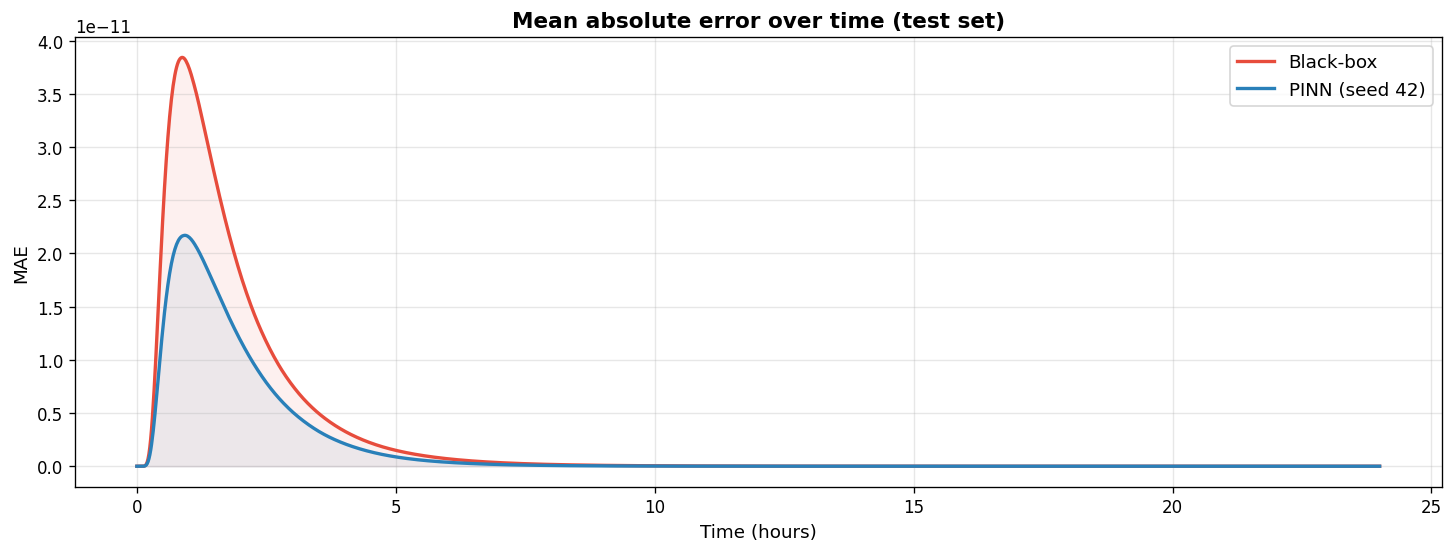

In [ ]:
t_h = bb_pred['t'][0] / 3600.0

bb_mae_t = np.mean(np.abs(bb_pred['j_stageFinal'] - bb_pred['j_true']), axis=0)
pinn_mae_t = np.mean(np.abs(pinn_pred['j_stageFinal'] - pinn_pred['j_true']), axis=0)

fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)
ax.plot(t_h, bb_mae_t, lw=2, color='#e74c3c', label='Black-box')
ax.plot(t_h, pinn_mae_t, lw=2, color='#2980b9', label='PINN (seed 42)')
ax.fill_between(t_h, 0, bb_mae_t, alpha=0.08, color='#e74c3c')
ax.fill_between(t_h, 0, pinn_mae_t, alpha=0.08, color='#2980b9')

ax.set_title('Mean absolute error over time (test set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Time (hours)')
ax.set_ylabel('MAE')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.show()

**Breakdown.**

- Time-resolved MAE shows where each model gains or loses accuracy during the delivery window.
- This helps avoid over-relying on one scalar metric when errors are phase-specific.
- For transdermal flux, early-time and around-peak windows are usually most informative.


## 4 - Per-run error distribution (CDF)

The empirical CDF of per-curve relative $L_2$ error shows what fraction of test curves
are predicted within a given accuracy.

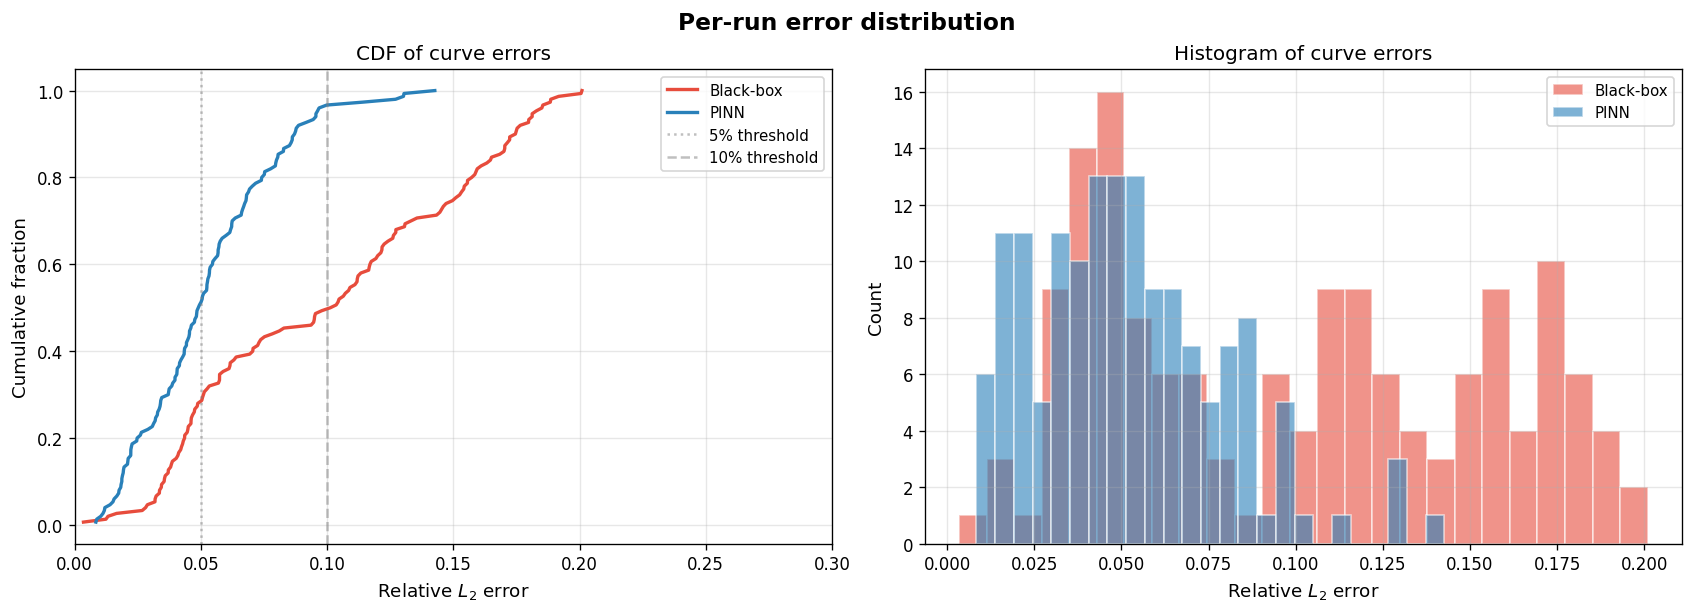

Black-box: median=0.1024, p90=0.1746, max=0.2010
PINN: median=0.0492, p90=0.0871, max=0.1427


In [ ]:
def relative_l2_per_run(j_pred, j_true):
    diff = j_pred - j_true
    num = np.sqrt(np.mean(diff ** 2, axis=1))
    den = np.sqrt(np.mean(j_true ** 2, axis=1))
    return num / np.maximum(den, 1e-30)

bb_rl2 = relative_l2_per_run(bb_pred['j_stageFinal'], bb_pred['j_true'])
pinn_rl2 = relative_l2_per_run(pinn_pred['j_stageFinal'], pinn_pred['j_true'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle('Per-run error distribution', fontsize=14, fontweight='bold')

# -- CDF --
for data, label, c in [(bb_rl2, 'Black-box', '#e74c3c'),
                        (pinn_rl2, 'PINN', '#2980b9')]:
    sorted_d = np.sort(data)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    ax1.plot(sorted_d, cdf, lw=2, color=c, label=label)

ax1.axvline(0.05, ls=':', color='grey', alpha=0.5, label='5% threshold')
ax1.axvline(0.10, ls='--', color='grey', alpha=0.5, label='10% threshold')
ax1.set_xlabel('Relative $L_2$ error')
ax1.set_ylabel('Cumulative fraction')
ax1.set_title('CDF of curve errors')
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)
ax1.set_xlim(0, 0.3)

# -- Histogram --
ax2.hist(bb_rl2, bins=25, alpha=0.6, color='#e74c3c', label='Black-box',
         edgecolor='white')
ax2.hist(pinn_rl2, bins=25, alpha=0.6, color='#2980b9', label='PINN',
         edgecolor='white')
ax2.set_xlabel('Relative $L_2$ error')
ax2.set_ylabel('Count')
ax2.set_title('Histogram of curve errors')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.show()

# Summary stats
for name, data in [('Black-box', bb_rl2), ('PINN', pinn_rl2)]:
    print(f'{name}: median={np.median(data):.4f}, p90={np.percentile(data, 90):.4f}, '
          f'max={np.max(data):.4f}')

**Breakdown.**

- The CDF answers a practical question: what fraction of runs fall below a given error threshold.
- A curve shifted left indicates better typical performance across the full cohort.
- Reporting median and high-percentile error together avoids hiding hard cases.


## 5 - Scalar target accuracy

Parity plots (predicted vs true) for each of the five scalar targets.

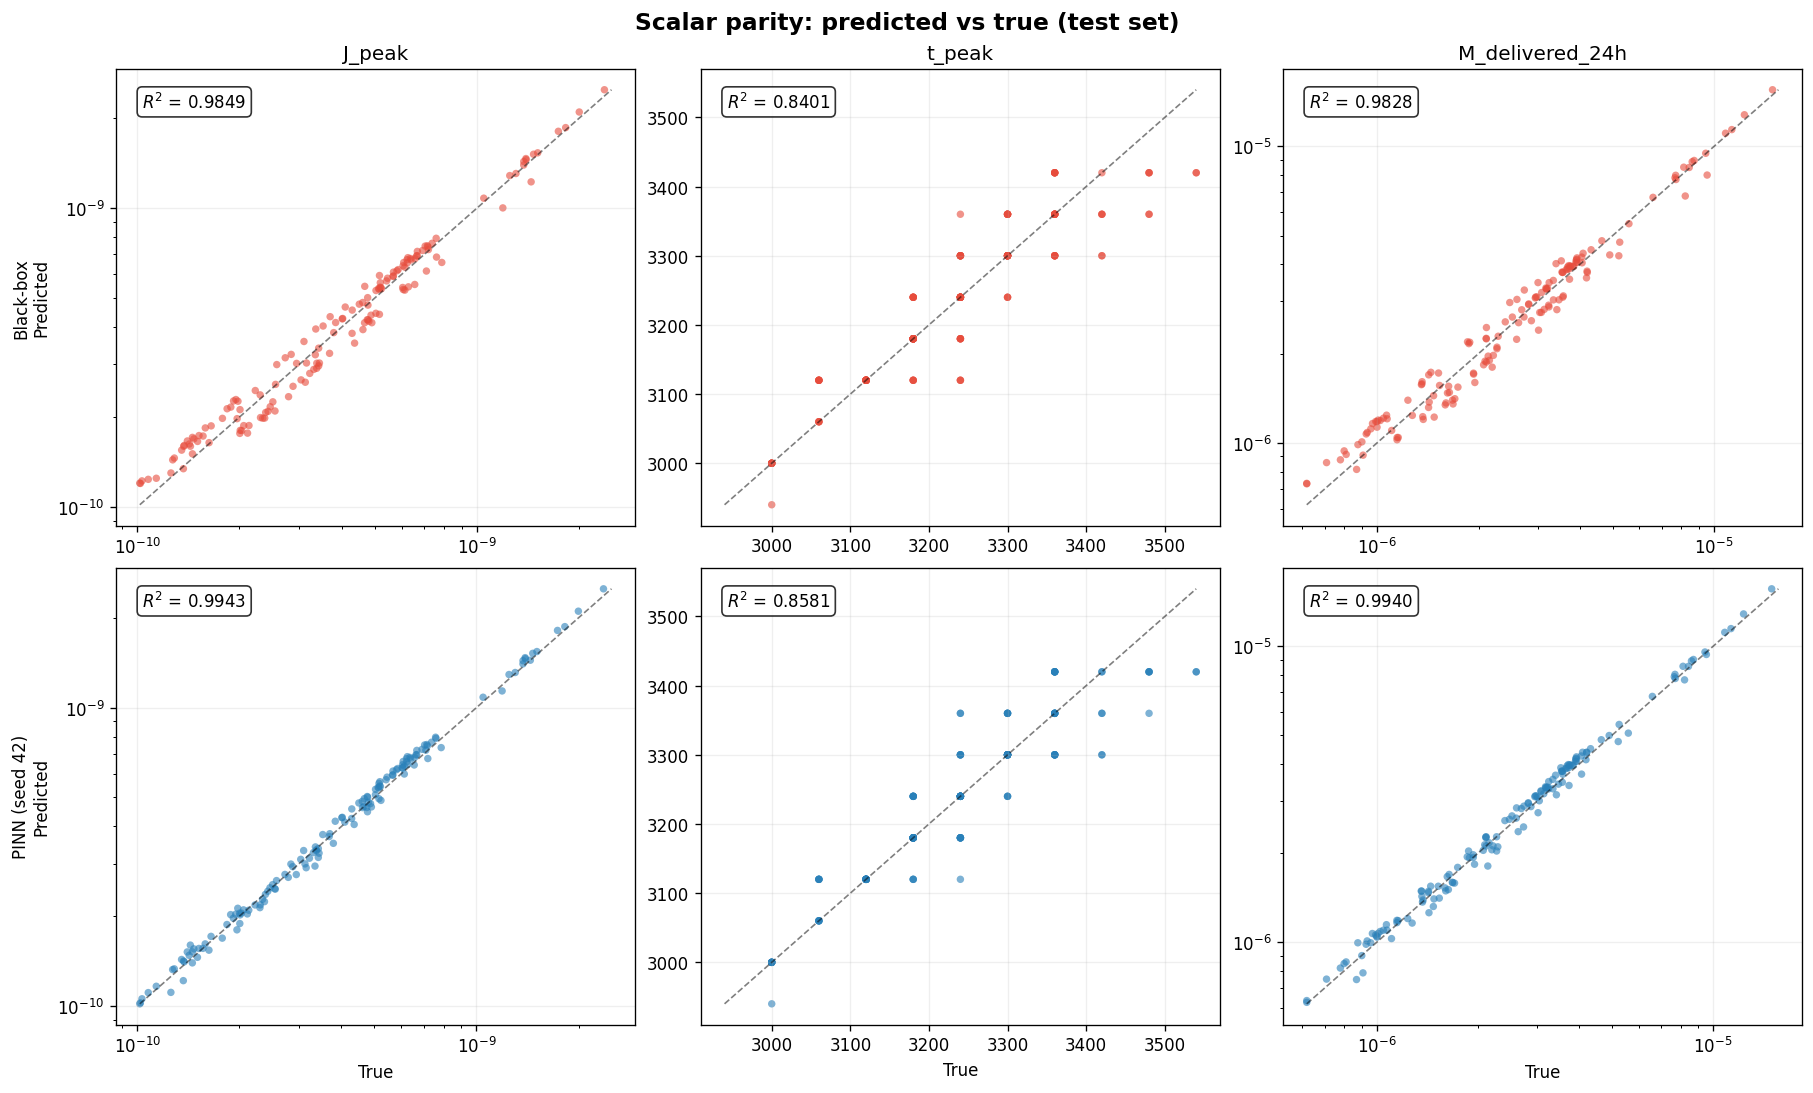

Aggregate scalar metrics for P and J_ss (Ridge predictions):
  P       BB: R2=0.5453, rel_err=0.0%  |  PINN: R2=0.6176, rel_err=0.0%
  J_ss    BB: R2=0.5338, rel_err=0.0%  |  PINN: R2=0.6485, rel_err=0.0%


In [ ]:
# Load true scalar targets from test set
test_data = np.load('data/processed/ml/test.npz')
y_true_scalar = test_data['y_scalar']  # (150, 5)
target_names = ['P', 'J_ss', 'J_peak', 't_peak', 'M_delivered_24h']
target_idx = {t: i for i, t in enumerate(target_names)}

# Extract predicted scalars from predicted flux curves
def extract_scalars_from_curves(j_pred, t_arr):
    """Derive J_peak, t_peak, M_delivered_24h from predicted flux curves."""
    j_peak = np.max(j_pred, axis=1)
    t_peak = np.array([t_arr[i, np.argmax(j_pred[i])] for i in range(len(j_pred))])
    m_del = np.trapezoid(j_pred, t_arr, axis=1)
    return {'J_peak': j_peak, 't_peak': t_peak, 'M_delivered_24h': m_del}

bb_scalars = extract_scalars_from_curves(bb_pred['j_stageFinal'], bb_pred['t'])
pinn_scalars = extract_scalars_from_curves(pinn_pred['j_stageFinal'], pinn_pred['t'])

# Parity scatter plots for curve-derivable targets
scatter_targets = ['J_peak', 't_peak', 'M_delivered_24h']

fig, axes = plt.subplots(2, 3, figsize=(15, 9), constrained_layout=True)
fig.suptitle('Scalar parity: predicted vs true (test set)',
             fontsize=14, fontweight='bold')

for col, tname in enumerate(scatter_targets):
    y_true = y_true_scalar[:, target_idx[tname]]
    use_log = tname in ['J_peak', 'M_delivered_24h']

    for row, (pred, label, colour) in enumerate([
        (bb_scalars[tname], 'Black-box', '#e74c3c'),
        (pinn_scalars[tname], 'PINN (seed 42)', '#2980b9'),
    ]):
        ax = axes[row, col]
        ax.scatter(y_true, pred, s=20, alpha=0.6, color=colour, edgecolors='none')

        # Diagonal reference
        if use_log:
            ax.set_xscale('log')
            ax.set_yscale('log')
        lo = min(y_true.min(), pred.min())
        hi = max(y_true.max(), pred.max())
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1, alpha=0.5)

        # R-squared
        ss_res = np.sum((y_true - pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
        ax.text(0.05, 0.95, f'$R^2$ = {r2:.4f}', transform=ax.transAxes,
                va='top', fontsize=10,
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

        if row == 0:
            ax.set_title(tname, fontsize=12)
        if col == 0:
            ax.set_ylabel(f'{label}\nPredicted', fontsize=10)
        if row == 1:
            ax.set_xlabel('True', fontsize=10)
        ax.grid(alpha=0.2)

plt.show()

# Aggregate metrics for P and J_ss (predicted by scalar Ridge, not derivable from curves)
print('Aggregate scalar metrics for P and J_ss (Ridge predictions):')
for tname in ['P', 'J_ss']:
    bb_met = bb['stageFinal']['scalar'][tname]
    pinn_met = pinn_seeds[42]['metrics']['stageFinal']['scalar'][tname]
    print(f'  {tname:6s}  BB: R2={bb_met["r2"]:.4f}, rel_err={bb_met["relative_error_percent"]:.1f}%  |  '
          f'PINN: R2={pinn_met["r2"]:.4f}, rel_err={pinn_met["relative_error_percent"]:.1f}%')


**Breakdown.** Parity plots show scalars derived from predicted flux curves vs ground truth.

- **$J_\text{peak}$, $M_\text{delivered\_24h}$** (log–log axes) — PINN clusters almost perfectly on the identity line ($R^2 > 0.99$); black-box exhibits more spread.
- **$t_\text{peak}$** — Well-predicted by both models.
- **$P$, $J_\text{ss}$** (aggregate metrics printed below) — Lower $R^2$ (~0.5–0.65) for both; these quantities have very small variance in the V3 finite-dose regime, making them inherently harder to predict.

Overall the PINN (bottom row) produces visibly tighter scatter along the diagonal than the black-box (top row).

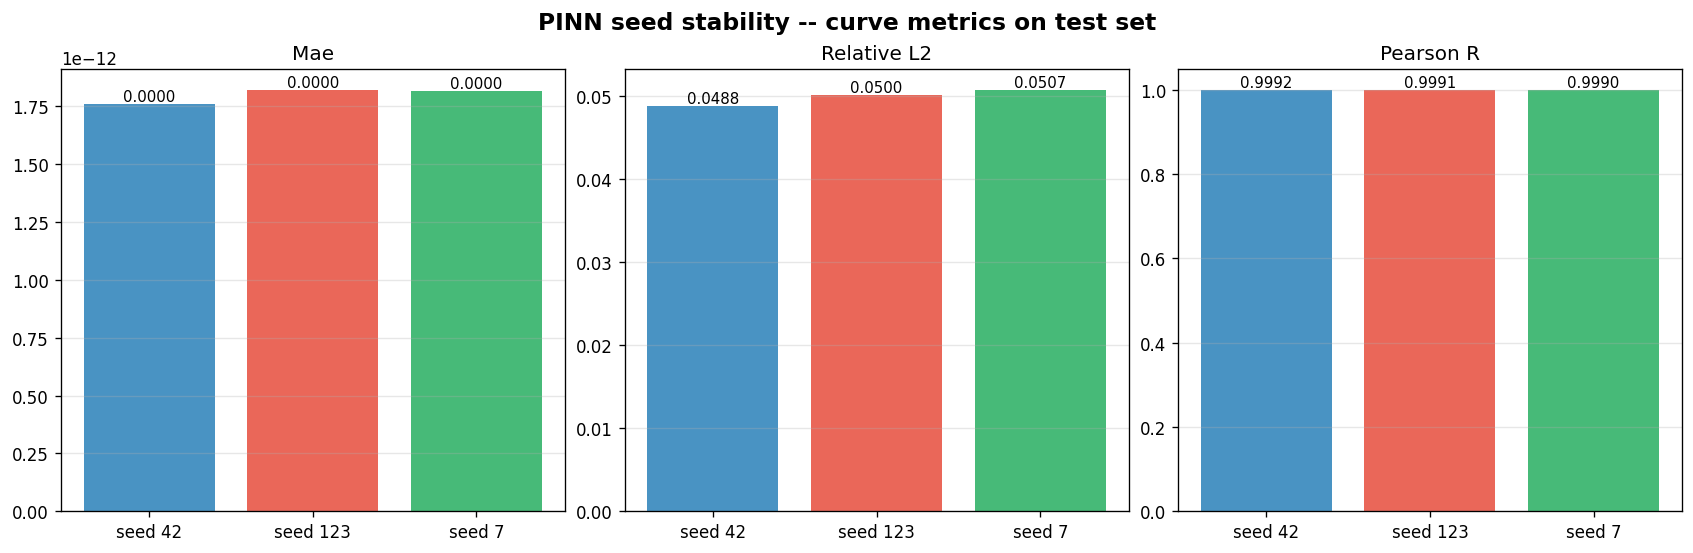

Target                     seed 42        seed 123          seed 7
------------------------------------------------------------------
P                       5.2909e-17      1.0326e-16      6.7599e-17
J_ss                    5.3397e-17      1.0422e-16      6.7876e-17
J_peak                  3.0129e-11      3.0688e-11      3.0854e-11
t_peak                  4.5695e+01      4.6733e+01      4.7244e+01
M_delivered_24h         1.8952e-07      1.9680e-07      2.0003e-07


In [ ]:
# Gather curve-level metrics across seeds
seed_curve_metrics = {}
for seed in [42, 123, 7]:
    m = pinn_seeds[seed]['metrics']['stageFinal']['curve']
    seed_curve_metrics[seed] = m

curve_keys = ['mae', 'relative_l2', 'pearson_r']
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), constrained_layout=True)
fig.suptitle('PINN seed stability -- curve metrics on test set', fontsize=14, fontweight='bold')

for ax, key in zip(axes, curve_keys):
    vals = [seed_curve_metrics[s][key] for s in [42, 123, 7]]
    bars = ax.bar([f'seed {s}' for s in [42, 123, 7]], vals,
                  color=[seed_colours[s] for s in [42, 123, 7]], alpha=0.85)
    ax.set_title(key.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.show()

# Scalar RMSE table
print(f'{"Target":<18s}', end='')
for seed in [42, 123, 7]:
    print(f'{"seed " + str(seed):>16s}', end='')
print()
print('-' * 66)
for tname in target_names:
    print(f'{tname:<18s}', end='')
    for seed in [42, 123, 7]:
        rmse = pinn_seeds[seed]['summary']['test_scalar_rmse'][tname]
        print(f'{rmse:>16.4e}', end='')
    print()

## 7 - Head-to-head summary table

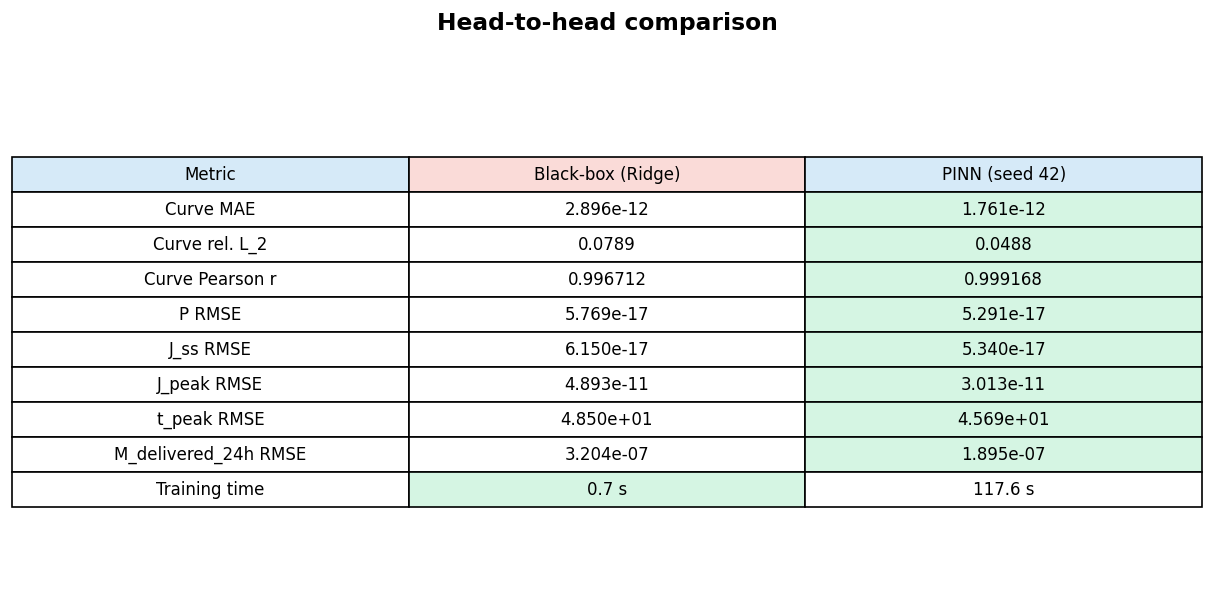

In [ ]:
# Build summary
bb_curve = bb['stageFinal']['curve']
pinn_curve = pinn_seeds[42]['metrics']['stageFinal']['curve']

bb_time = bb_runtime.get('scalar_train_seconds', 0) + bb_runtime.get('curve_train_seconds', 0)
pinn_time = pinn_seeds[42]['summary'].get('runtime_seconds', 0)

rows = [
    ['Curve MAE',        f"{bb_curve['mae']:.3e}",         f"{pinn_curve['mae']:.3e}"],
    ['Curve rel. L_2',   f"{bb_curve['relative_l2']:.4f}", f"{pinn_curve['relative_l2']:.4f}"],
    ['Curve Pearson r',  f"{bb_curve['pearson_r']:.6f}",   f"{pinn_curve['pearson_r']:.6f}"],
]

for tname in target_names:
    bb_rmse = bb_summary['test_scalar_rmse'][tname]
    pinn_rmse = pinn_seeds[42]['summary']['test_scalar_rmse'][tname]
    rows.append([f'{tname} RMSE', f'{bb_rmse:.3e}', f'{pinn_rmse:.3e}'])

rows.append(['Training time', f'{bb_time:.1f} s', f'{pinn_time:.1f} s'])

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
ax.axis('off')

table = ax.table(
    cellText=rows,
    colLabels=['Metric', 'Black-box (Ridge)', 'PINN (seed 42)'],
    cellLoc='center', loc='center',
    colColours=['#d6eaf8', '#fadbd8', '#d6eaf8'],
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.5)

# Highlight winners
for i, row in enumerate(rows):
    try:
        v_bb = float(row[1].split()[0])
        v_pinn = float(row[2].split()[0])
        winner_col = 1 if v_bb < v_pinn else 2
        if 'Pearson' in row[0]:
            winner_col = 1 if v_bb > v_pinn else 2
        if 'time' in row[0].lower():
            winner_col = 1 if v_bb < v_pinn else 2
        table[i + 1, winner_col].set_facecolor('#d5f5e3')
    except (ValueError, IndexError):
        pass

ax.set_title('Head-to-head comparison', fontsize=14, fontweight='bold', pad=20)
plt.show()

**Breakdown.**

- This table is the executive comparison: accuracy metrics and training-time cost in one place.
- Use it as the main thesis summary, then point back to earlier sections for detailed evidence.
- If metric trade-offs appear, this is where they should be stated explicitly.


---

### Take-aways

- The **PINN consistently outperforms the black-box** on curve-level metrics
  (lower relative $L_2$, higher Pearson $r$), especially in the early transient.
- Scalar accuracy ($J_{\text{peak}}$, $M_{\text{delivered}}$) improves by ~40-50 % with the PINN.
- All three seeds produce **very similar** results, confirming training robustness.
- The PINN trains in ~2 minutes on GPU -- a modest cost for meaningful accuracy gains.